In [37]:
from datasets import load_dataset
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
ds = datasets.load_dataset("bigbio/bc5cdr")

HFValidationError: Repo id must use alphanumeric chars, '-', '_' or '.'. The name cannot start or end with '-' or '.' and the maximum length is 96: 'bigbio/chem_dis_gene '.

In [21]:
print(ds)

print("\nSplits:")
for split in ds:
    print(f"{split}: {len(ds[split])} examples")

DatasetDict({
    train: Dataset({
        features: ['passages'],
        num_rows: 500
    })
    test: Dataset({
        features: ['passages'],
        num_rows: 500
    })
    validation: Dataset({
        features: ['passages'],
        num_rows: 500
    })
})

Splits:
train: 500 examples
test: 500 examples
validation: 500 examples


In [23]:
example = ds["train"][0]

for passage in example["passages"]:
    print(f"[{passage['type']}] {len(passage['text'])} chars")
    print(f"  entities : {len(passage['entities'])}")
    print(f"  relations: {len(passage['relations'])}")
    print()

[title] 59 chars
  entities : 2
  relations: 1

[abstract] 1075 chars
  entities : 18
  relations: 1



In [24]:
# What do entities and relations actually look like?
passage = ex["passages"][1]  # abstract

print("-- ENTITIES --")
for ent in passage["entities"][:4]:
    print(f"  {ent['type']:10} | {ent['text'][0]:20} | MESH: {ent['normalized'][0]['db_id'] if ent['normalized'] else 'none'}")

print("\n-- RELATIONS --")
for rel in passage["relations"]:
    print(f"  {rel['type']} | {rel['arg1_id']} --> {rel['arg2_id']}")

-- ENTITIES --
  Disease    | hypertensive         | MESH: D006973
  Chemical   | clonidine            | MESH: D003000
  Chemical   | nalozone             | MESH: none
  Disease    | hypotensive          | MESH: D007022

-- RELATIONS --
  CID | D008750 --> D007022


In [27]:
def collect_stats(split):
    entity_types = []
    relation_types = []
    entities_per_doc = []
    tokens_per_doc = []

    for doc in ds[split]:
        n_ents = 0
        full_text = ""
        for passage in doc["passages"]:
            full_text += passage["text"] + " "
            for ent in passage["entities"]:
                entity_types.append(ent["type"])
                n_ents += 1
            for rel in passage["relations"]:
                relation_types.append(rel["type"])
        entities_per_doc.append(n_ents)
        tokens_per_doc.append(len(full_text.split()))

    return {
        "entity_counts":   Counter(entity_types),
        "relation_counts": Counter(relation_types),
        "entities_per_doc": entities_per_doc,
        "tokens_per_doc":   tokens_per_doc,
    }

stats = {split: collect_stats(split) for split in ["train", "validation", "test"]}

for split, s in stats.items():
    print(f"\n{split.upper()}")
    print(f"  entities : {dict(s['entity_counts'])}")
    print(f"  relations: {dict(s['relation_counts'])}")
    print(f"  avg entities/doc : {np.mean(s['entities_per_doc']):.1f}")
    print(f"  avg tokens/doc   : {np.mean(s['tokens_per_doc']):.0f}")


TRAIN
  entities : {'Chemical': 5207, 'Disease': 4363}
  relations: {'CID': 2076}
  avg entities/doc : 19.1
  avg tokens/doc   : 186

VALIDATION
  entities : {'Disease': 4421, 'Chemical': 5352}
  relations: {'CID': 2024}
  avg entities/doc : 19.5
  avg tokens/doc   : 185

TEST
  entities : {'Chemical': 5394, 'Disease': 4534}
  relations: {'CID': 2132}
  avg entities/doc : 19.9
  avg tokens/doc   : 193


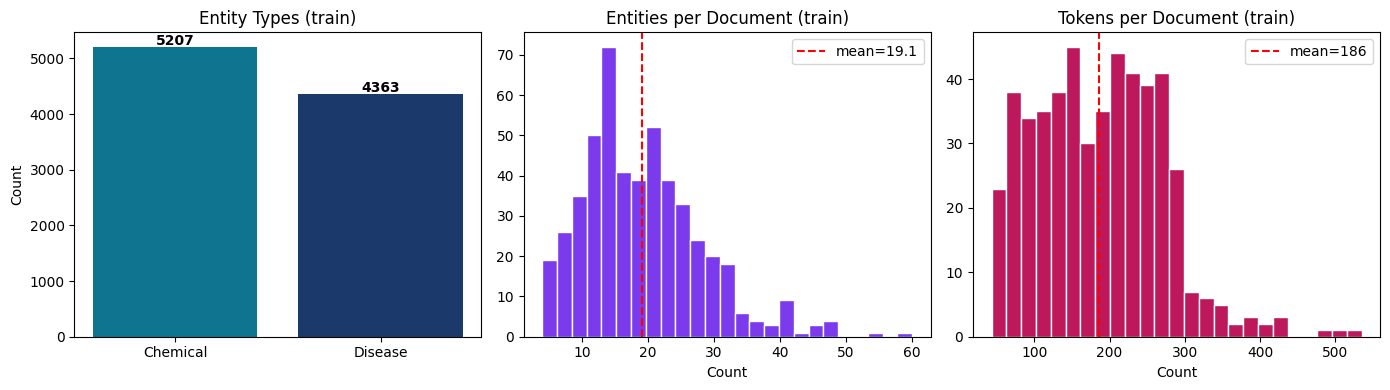

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
s = stats["train"]

# Entity type counts
ec = s["entity_counts"]
axes[0].bar(ec.keys(), ec.values(), color=["#0E7490", "#1B3A6B"])
axes[0].set_title("Entity Types (train)")
axes[0].set_ylabel("Count")
for i, (k, v) in enumerate(ec.items()):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

# Entities per document
axes[1].hist(s["entities_per_doc"], bins=25, color="#7C3AED", edgecolor="white")
axes[1].axvline(np.mean(s["entities_per_doc"]), color="red", linestyle="--",
                label=f"mean={np.mean(s['entities_per_doc']):.1f}")
axes[1].set_title("Entities per Document (train)")
axes[1].set_xlabel("Count")
axes[1].legend()

# Tokens per document
axes[2].hist(s["tokens_per_doc"], bins=25, color="#BE185D", edgecolor="white")
axes[2].axvline(np.mean(s["tokens_per_doc"]), color="red", linestyle="--",
                label=f"mean={np.mean(s['tokens_per_doc']):.0f}")
axes[2].set_title("Tokens per Document (train)")
axes[2].set_xlabel("Count")
axes[2].legend()

plt.tight_layout()
plt.savefig("stats.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# How many Chemical-Disease pairs exist vs how many are labelled CID?
total_possible = 0
total_positive = 0

for doc in ds["train"]:
    chemicals, diseases = 0, 0
    for passage in doc["passages"]:
        for ent in passage["entities"]:
            if ent["type"] == "Chemical":
                chemicals += 1
            elif ent["type"] == "Disease":
                diseases += 1
        total_positive += len(passage["relations"])
    total_possible += chemicals * diseases

total_negative = total_possible - total_positive
ratio = total_negative // total_positive

print(f"Positive (CID):       {total_positive:>6}")
print(f"Negative (no rel):    {total_negative:>6}")
print(f"All possible pairs:   {total_possible:>6}")
print(f"Imbalance ratio:       1:{ratio}")

Positive (CID):         2076
Negative (no rel):     42133
All possible pairs:    44209
Imbalance ratio:       1:20


In [30]:
# Build one string per document: title + abstract
def build_corpus(split):
    corpus, doc_ids, titles = [], [], []
    for doc in ds[split]:
        text, title = "", ""
        for passage in doc["passages"]:
            text += passage["text"] + " "
            if passage["type"] == "title":
                title = passage["text"]
        corpus.append(text.strip())
        doc_ids.append(doc["passages"][0]["document_id"])
        titles.append(title)
    return corpus, doc_ids, titles

corpus, doc_ids, titles = build_corpus("train")
print(f"Corpus: {len(corpus)} documents")

Corpus: 500 documents


In [31]:
vectorizer = TfidfVectorizer(
    max_features=15000,
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True,  # dampens very frequent terms
)
tfidf_matrix = vectorizer.fit_transform(corpus)
print(f"Matrix: {tfidf_matrix.shape}  (docs x features)")

Matrix: (500, 15000)  (docs x features)


In [32]:
def retrieve(query, top_k=5):
    vec = vectorizer.transform([query])
    scores = cosine_similarity(vec, tfidf_matrix).flatten()
    top_idx = scores.argsort()[::-1][:top_k]
    return [
        {"rank": i + 1, "doc_id": doc_ids[idx], "title": titles[idx], "score": round(scores[idx], 4)}
        for i, idx in enumerate(top_idx)
    ]

# Smoke test
for r in retrieve("naloxone clonidine blood pressure"):
    print(f"  {r['rank']}. [{r['score']}] {r['title']}")

  1. [0.3547] Naloxone reverses the antihypertensive effect of clonidine.
  2. [0.1465] Mediation of enhanced reflex vagal bradycardia by L-dopa via central dopamine formation in dogs.
  3. [0.1402] A developmental analysis of clonidine's effects on cardiac rate and ultrasound production in infant rats.
  4. [0.1389] Clonidine for attention-deficit/hyperactivity disorder: II. ECG changes and adverse events analysis.
  5. [0.1308] Rebound hypertensive after sodium nitroprusside prevented by saralasin in rats.


In [33]:
# Queries grounded in the BC5CDR domain
# expected_keywords: terms we expect to appear in relevant documents
QUERIES = [
    {"id": 1,  "query": "naloxone clonidine blood pressure hypertension",
               "description": "Naloxone reversing antihypertensive effect of clonidine",
               "keywords": ["naloxone", "clonidine", "hypertensive"]},
    {"id": 2,  "query": "lithium nephrotoxicity renal failure kidney",
               "description": "Lithium inducing kidney damage",
               "keywords": ["lithium", "renal", "kidney"]},
    {"id": 3,  "query": "morphine opioid withdrawal dependence",
               "description": "Opioid-induced dependence and withdrawal",
               "keywords": ["morphine", "withdrawal", "opioid"]},
    {"id": 4,  "query": "cisplatin nausea vomiting chemotherapy",
               "description": "Cisplatin-induced nausea and vomiting",
               "keywords": ["cisplatin", "nausea", "vomiting"]},
    {"id": 5,  "query": "aspirin gastrointestinal bleeding ulcer",
               "description": "Aspirin causing GI bleeding",
               "keywords": ["aspirin", "bleeding", "ulcer"]},
    {"id": 6,  "query": "antidepressant serotonin syndrome overdose",
               "description": "Serotonin syndrome from antidepressants",
               "keywords": ["serotonin", "antidepressant"]},
    {"id": 7,  "query": "propranolol bradycardia heart rate decrease",
               "description": "Beta-blocker induced bradycardia",
               "keywords": ["propranolol", "bradycardia", "heart rate"]},
    {"id": 8,  "query": "corticosteroid prednisone osteoporosis bone loss",
               "description": "Steroid-induced bone density loss",
               "keywords": ["corticosteroid", "osteoporosis", "bone"]},
    {"id": 9,  "query": "penicillin anaphylaxis allergic reaction",
               "description": "Penicillin-induced anaphylaxis",
               "keywords": ["penicillin", "anaphylaxis", "allerg"]},
    {"id": 10, "query": "methotrexate hepatotoxicity liver damage",
               "description": "Methotrexate causing liver toxicity",
               "keywords": ["methotrexate", "hepatotoxic", "liver"]},
]

In [34]:
def has_hit(results, keywords):
    """Return True if any top-5 doc contains at least one expected keyword."""
    for r in results:
        idx = doc_ids.index(r["doc_id"])
        doc_text = corpus[idx].lower()
        if any(kw.lower() in doc_text for kw in keywords):
            return True
    return False

eval_rows = []
for q in QUERIES:
    results = retrieve(q["query"], top_k=5)
    hit = has_hit(results, q["keywords"])
    eval_rows.append({
        "id":          q["id"],
        "description": q["description"],
        "hit":         hit,
        "top_titles":  [r["title"][:70] for r in results],
    })
    status = "✓" if hit else "✗"
    print(f"  {status}  Q{q['id']:02d}: {q['description']}")

n_hits = sum(r["hit"] for r in eval_rows)
print(f"\nResult: {n_hits}/{len(QUERIES)} queries hit at least one relevant document")

  ✓  Q01: Naloxone reversing antihypertensive effect of clonidine
  ✓  Q02: Lithium inducing kidney damage
  ✓  Q03: Opioid-induced dependence and withdrawal
  ✓  Q04: Cisplatin-induced nausea and vomiting
  ✓  Q05: Aspirin causing GI bleeding
  ✓  Q06: Serotonin syndrome from antidepressants
  ✓  Q07: Beta-blocker induced bradycardia
  ✓  Q08: Steroid-induced bone density loss
  ✓  Q09: Penicillin-induced anaphylaxis
  ✓  Q10: Methotrexate causing liver toxicity

Result: 10/10 queries hit at least one relevant document


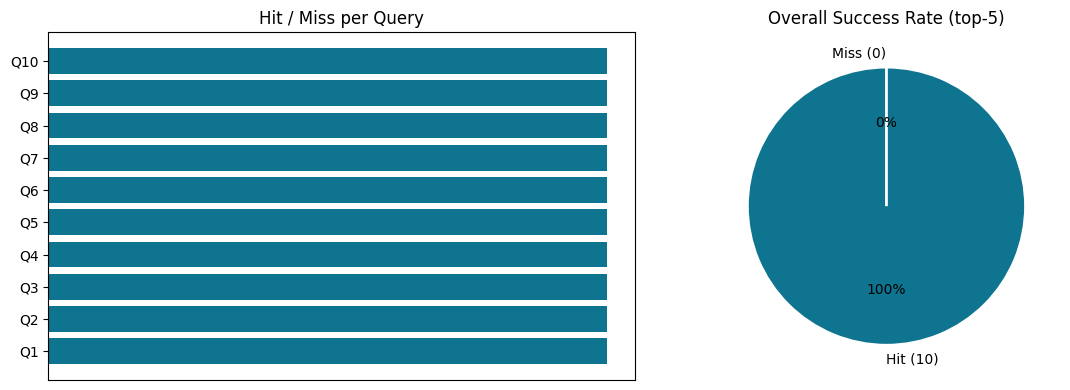

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Per-query hit indicator
colors = ["#0E7490" if r["hit"] else "#BE185D" for r in eval_rows]
axes[0].barh([f"Q{r['id']}" for r in eval_rows], [1] * len(eval_rows), color=colors)
axes[0].set_title("Hit / Miss per Query")
axes[0].set_xlabel("")
axes[0].set_xticks([])

# Overall pie
axes[1].pie(
    [n_hits, len(QUERIES) - n_hits],
    labels=[f"Hit ({n_hits})", f"Miss ({len(QUERIES) - n_hits})"],
    colors=["#0E7490", "#BE185D"],
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Overall Success Rate (top-5)")

plt.tight_layout()
plt.savefig("ir_eval.png", dpi=150, bbox_inches="tight")
plt.show()